In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

FEATURES_DIR = Path('../../data/features')
MODELS_DIR = Path('../../data/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')

Imports OK


In [2]:
df = pd.read_parquet(FEATURES_DIR / 'feature_matrix_v2.parquet')
with open(FEATURES_DIR / 'feature_meta_v2.json') as f:
    meta = json.load(f)

print(f'Full dataset: {df.shape[0]:,} samples × {df.shape[1]} columns')
print(f'Time range: {df["t0"].min().date()} → {df["t0"].max().date()} ({(df["t0"].max() - df["t0"].min()).days} days)')
print(f'Tokens: {df["token_id"].nunique()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().sort_index())
print(f'\nBarrier type:')
print(df['barrier_type'].value_counts())

Full dataset: 43,461 samples × 94 columns
Time range: 2025-12-05 → 2026-03-05 (90 days)
Tokens: 592

Label distribution:
label
-1    17546
 0     8378
 1    17537
Name: count, dtype: int64

Barrier type:
barrier_type
vertical    23908
sl           9795
tp           9758
Name: count, dtype: int64


In [3]:
df_bin = df[df['label'] != 0].copy()
df_bin['y'] = (df_bin['label'] == 1).astype(int)

print(f'Binary dataset: {len(df_bin):,} samples')
print(f'Class balance: TP={df_bin["y"].mean():.3f}, SL={1-df_bin["y"].mean():.3f}')

Binary dataset: 35,083 samples
Class balance: TP=0.500, SL=0.500


In [4]:
all_numeric = meta['numeric_features']

nan_rates = df_bin[all_numeric].isnull().mean()
good_features = nan_rates[nan_rates < 0.05].index.tolist()
sparse_features = nan_rates[nan_rates >= 0.50].index.tolist()

print(f'Good features (<5% NaN): {len(good_features)}')
print(f'Sparse features (>50% NaN): {len(sparse_features)} — will drop for baseline')
print(f'\nUsing {len(good_features)} features for modeling')

std_check = df_bin[good_features].std()
constant = std_check[std_check < 1e-10].index.tolist()
if constant:
    print(f'Dropping {len(constant)} constant features: {constant}')
    good_features = [f for f in good_features if f not in constant]

FEATURES = good_features
print(f'Final feature set: {len(FEATURES)} features')

Good features (<5% NaN): 63
Sparse features (>50% NaN): 0 — will drop for baseline

Using 63 features for modeling
Final feature set: 63 features


In [5]:
df_bin = df_bin.sort_values('t0').reset_index(drop=True)

n = len(df_bin)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df_bin.iloc[:train_end]
val = df_bin.iloc[train_end:val_end]
test = df_bin.iloc[val_end:]

print(f'Train: {len(train):,} samples ({train["t0"].min().date()} → {train["t0"].max().date()})')
print(f'Val:   {len(val):,} samples ({val["t0"].min().date()} → {val["t0"].max().date()})')
print(f'Test:  {len(test):,} samples ({test["t0"].min().date()} → {test["t0"].max().date()})')
print(f'\nClass balance — Train: {train["y"].mean():.3f}, Val: {val["y"].mean():.3f}, Test: {test["y"].mean():.3f}')

X_train, y_train = train[FEATURES].values, train['y'].values
X_val, y_val = val[FEATURES].values, val['y'].values
X_test, y_test = test[FEATURES].values, test['y'].values

train_medians = np.nanmedian(X_train, axis=0)
for i in range(X_train.shape[1]):
    mask = np.isnan(X_train[:, i])
    X_train[mask, i] = train_medians[i]
    X_val[np.isnan(X_val[:, i]), i] = train_medians[i]
    X_test[np.isnan(X_test[:, i]), i] = train_medians[i]

print(f'\nNaN after imputation: train={np.isnan(X_train).sum()}, val={np.isnan(X_val).sum()}, test={np.isnan(X_test).sum()}')

Train: 24,558 samples (2025-12-05 → 2026-02-06)
Val:   5,262 samples (2026-02-06 → 2026-02-22)
Test:  5,263 samples (2026-02-22 → 2026-03-05)

Class balance — Train: 0.499, Val: 0.500, Test: 0.504

NaN after imputation: train=0, val=0, test=0


In [6]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, scale=False):
    """Train, predict, evaluate, store results."""
    t0 = time.time()

    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    ll = log_loss(y_te, y_prob)

    results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'logloss': ll, 'time': elapsed}
    print(f'{name:25s} | acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | logloss={ll:.4f} | {elapsed:.1f}s')
    return model

print(f'Evaluating on validation set ({len(y_val):,} samples)\n')
print(f'{"Model":25s} | {"Acc":>8s} | {"F1":>8s} | {"AUC":>8s} | {"LogLoss":>8s} | Time')
print('-' * 85)

from sklearn.dummy import DummyClassifier
evaluate('Dummy (most frequent)', DummyClassifier(strategy='most_frequent', random_state=SEED), X_train, y_train, X_val, y_val)

lr = evaluate('LogisticRegression', LogisticRegression(max_iter=1000, random_state=SEED), X_train, y_train, X_val, y_val, scale=True)

rf = evaluate('RandomForest', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20, random_state=SEED, n_jobs=-1), X_train, y_train, X_val, y_val)

Evaluating on validation set (5,262 samples)

Model                     |      Acc |       F1 |      AUC |  LogLoss | Time
-------------------------------------------------------------------------------------
Dummy (most frequent)     | acc=0.4996 | F1=0.0000 | AUC=0.5000 | logloss=18.0355 | 0.0s


LogisticRegression        | acc=0.6366 | F1=0.6341 | AUC=0.6706 | logloss=0.6501 | 0.1s


RandomForest              | acc=0.6412 | F1=0.6412 | AUC=0.6893 | logloss=0.6373 | 1.1s


In [7]:
def xgb_objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'random_state': SEED,
        'n_jobs': -1,
        'verbosity': 0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

print('XGBoost Optuna tuning (50 trials)...')
t0 = time.time()
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
elapsed_xgb = time.time() - t0

print(f'\nBest AUC: {study_xgb.best_value:.4f} (trial {study_xgb.best_trial.number})')
print(f'Time: {elapsed_xgb:.0f}s ({elapsed_xgb/60:.1f} min)')
print(f'Best params: {study_xgb.best_params}')

XGBoost Optuna tuning (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.681526:   0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.681526:   2%|▏         | 1/50 [00:00<00:28,  1.75it/s]

Best trial: 1. Best value: 0.683039:   2%|▏         | 1/50 [00:01<00:28,  1.75it/s]

...

Best trial: 26. Best value: 0.695273:  98%|█████████▊| 49/50 [00:44<00:01,  1.06s/it]

Best trial: 26. Best value: 0.695273:  98%|█████████▊| 49/50 [00:46<00:01,  1.06s/it]

Best trial: 26. Best value: 0.695273: 100%|██████████| 50/50 [00:46<00:00,  1.21s/it]

Best trial: 26. Best value: 0.695273: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]


Best AUC: 0.6953 (trial 26)
Time: 46s (0.8 min)
Best params: {'n_estimators': 266, 'max_depth': 9, 'learning_rate': 0.03353518349792729, 'subsample': 0.5452463289289573, 'colsample_bytree': 0.5574986999008571, 'min_child_weight': 32, 'reg_alpha': 4.648910729510291e-06, 'reg_lambda': 1.2707930936373432e-05, 'gamma': 0.5318638360110206}


In [8]:
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({'objective': 'binary:logistic', 'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})

xgb_best = xgb.XGBClassifier(**best_xgb_params)
xgb_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_prob_xgb = xgb_best.predict_proba(X_val)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

results['XGBoost (tuned)'] = {
    'accuracy': accuracy_score(y_val, y_pred_xgb),
    'f1': f1_score(y_val, y_pred_xgb),
    'auc': roc_auc_score(y_val, y_prob_xgb),
    'logloss': log_loss(y_val, y_prob_xgb),
    'time': elapsed_xgb,
}

print(f'XGBoost (tuned) on val:')
print(classification_report(y_val, y_pred_xgb, target_names=['SL', 'TP']))

XGBoost (tuned) on val:
              precision    recall  f1-score   support

          SL       0.64      0.65      0.64      2629
          TP       0.64      0.63      0.64      2633

    accuracy                           0.64      5262
   macro avg       0.64      0.64      0.64      5262
weighted avg       0.64      0.64      0.64      5262



In [9]:
def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

print('LightGBM Optuna tuning (50 trials)...')
t0 = time.time()
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
elapsed_lgb = time.time() - t0

print(f'\nBest AUC: {study_lgb.best_value:.4f} (trial {study_lgb.best_trial.number})')
print(f'Time: {elapsed_lgb:.0f}s ({elapsed_lgb/60:.1f} min)')
print(f'Best params: {study_lgb.best_params}')

LightGBM Optuna tuning (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.676159:   0%|          | 0/50 [00:03<?, ?it/s]

Best trial: 0. Best value: 0.676159:   2%|▏         | 1/50 [00:03<03:15,  3.99s/it]

Best trial: 0. Best value: 0.676159:   2%|▏         | 1/50 [00:04<03:15,  3.99s/it]

...

Best trial: 17. Best value: 0.693051:  98%|█████████▊| 49/50 [02:32<00:03,  3.21s/it]

Best trial: 17. Best value: 0.693051:  98%|█████████▊| 49/50 [02:35<00:03,  3.21s/it]

Best trial: 17. Best value: 0.693051: 100%|██████████| 50/50 [02:35<00:00,  3.28s/it]

Best trial: 17. Best value: 0.693051: 100%|██████████| 50/50 [02:35<00:00,  3.11s/it]


Best AUC: 0.6931 (trial 17)
Time: 155s (2.6 min)
Best params: {'n_estimators': 458, 'max_depth': 10, 'learning_rate': 0.018965996720683862, 'num_leaves': 47, 'subsample': 0.6580601718218131, 'colsample_bytree': 0.31798953348443026, 'min_child_samples': 86, 'reg_alpha': 9.863866931631554, 'reg_lambda': 9.402122237270941}


In [10]:
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({'objective': 'binary', 'random_state': SEED, 'n_jobs': -1, 'verbose': -1})

lgb_best = lgb.LGBMClassifier(**best_lgb_params)
lgb_best.fit(X_train, y_train, eval_set=[(X_val, y_val)])

y_prob_lgb = lgb_best.predict_proba(X_val)[:, 1]
y_pred_lgb = (y_prob_lgb > 0.5).astype(int)

results['LightGBM (tuned)'] = {
    'accuracy': accuracy_score(y_val, y_pred_lgb),
    'f1': f1_score(y_val, y_pred_lgb),
    'auc': roc_auc_score(y_val, y_prob_lgb),
    'logloss': log_loss(y_val, y_prob_lgb),
    'time': elapsed_lgb,
}

print(f'LightGBM (tuned) on val:')
print(classification_report(y_val, y_pred_lgb, target_names=['SL', 'TP']))

LightGBM (tuned) on val:
              precision    recall  f1-score   support

          SL       0.64      0.64      0.64      2629
          TP       0.64      0.64      0.64      2633

    accuracy                           0.64      5262
   macro avg       0.64      0.64      0.64      5262
weighted avg       0.64      0.64      0.64      5262



In [11]:
def purged_kfold(t0_series, t1_series, n_splits=5, embargo_pct=0.01):
    """PurgedKFold split (AFML ch.7).

    For each fold:
    - Test set = contiguous time block
    - Train set = all other samples, MINUS those whose [t0,t1]
      overlaps with test period, PLUS embargo buffer after test end.

    Returns: list of (train_idx, test_idx) tuples
    """
    n = len(t0_series)
    embargo = int(n * embargo_pct)

    indices = np.arange(n)
    fold_size = n // n_splits
    splits = []

    t0_arr = t0_series.values
    t1_arr = t1_series.values

    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size if i < n_splits - 1 else n
        test_idx = indices[test_start:test_end]

        test_t0_min = t0_arr[test_start]
        test_t0_max = t0_arr[test_end - 1]

        train_mask = np.ones(n, dtype=bool)
        train_mask[test_start:test_end] = False

        for j in range(test_start):
            if t1_arr[j] >= test_t0_min:
                train_mask[j] = False

        embargo_end = min(test_end + embargo, n)
        train_mask[test_end:embargo_end] = False

        train_idx = indices[train_mask]
        splits.append((train_idx, test_idx))

    return splits

pkf_splits = purged_kfold(df_bin['t0'], df_bin['t1'], n_splits=5, embargo_pct=0.01)

print('PurgedKFold splits:')
for i, (tr, te) in enumerate(pkf_splits):
    purged = len(df_bin) - len(tr) - len(te)
    print(f'  Fold {i}: train={len(tr):,}, test={len(te):,}, purged+embargo={purged}')

PurgedKFold splits:
  Fold 0: train=27,717, test=7,016, purged+embargo=350
  Fold 1: train=27,471, test=7,016, purged+embargo=596
  Fold 2: train=27,433, test=7,016, purged+embargo=634
  Fold 3: train=27,375, test=7,016, purged+embargo=692
  Fold 4: train=27,872, test=7,019, purged+embargo=192


In [12]:
X_all = df_bin[FEATURES].values.copy()
y_all = df_bin['y'].values.copy()

def cv_with_purged_kfold(model_class, params, splits, X, y):
    scores = {'accuracy': [], 'auc': [], 'f1': [], 'logloss': []}
    for fold_i, (tr_idx, te_idx) in enumerate(splits):
        X_tr, y_tr = X[tr_idx].copy(), y[tr_idx]
        X_te, y_te = X[te_idx].copy(), y[te_idx]

        medians = np.nanmedian(X_tr, axis=0)
        for j in range(X_tr.shape[1]):
            X_tr[np.isnan(X_tr[:, j]), j] = medians[j]
            X_te[np.isnan(X_te[:, j]), j] = medians[j]

        model = model_class(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        scores['accuracy'].append(accuracy_score(y_te, y_pred))
        scores['auc'].append(roc_auc_score(y_te, y_prob))
        scores['f1'].append(f1_score(y_te, y_pred))
        scores['logloss'].append(log_loss(y_te, y_prob))

    return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}

print('PurgedKFold CV (5 folds)...')
print(f'\n{"Metric":10s} | {"XGBoost":20s} | {"LightGBM":20s}')
print('-' * 55)

t0 = time.time()
cv_xgb = cv_with_purged_kfold(xgb.XGBClassifier, best_xgb_params, pkf_splits, X_all, y_all)
cv_lgb = cv_with_purged_kfold(lgb.LGBMClassifier, best_lgb_params, pkf_splits, X_all, y_all)
cv_time = time.time() - t0

for metric in ['accuracy', 'auc', 'f1', 'logloss']:
    xm, xs = cv_xgb[metric]
    lm, ls = cv_lgb[metric]
    print(f'{metric:10s} | {xm:.4f} ± {xs:.4f}      | {lm:.4f} ± {ls:.4f}')

print(f'\nCV time: {cv_time:.0f}s')

results['XGBoost (PurgedCV)'] = {k: v[0] for k, v in cv_xgb.items()}
results['LightGBM (PurgedCV)'] = {k: v[0] for k, v in cv_lgb.items()}

PurgedKFold CV (5 folds)...

Metric     | XGBoost              | LightGBM            
-------------------------------------------------------


accuracy   | 0.6512 ± 0.0231      | 0.6557 ± 0.0254
auc        | 0.7058 ± 0.0325      | 0.7088 ± 0.0337
f1         | 0.6517 ± 0.0236      | 0.6559 ± 0.0244
logloss    | 0.6250 ± 0.0246      | 0.6225 ± 0.0252

CV time: 19s


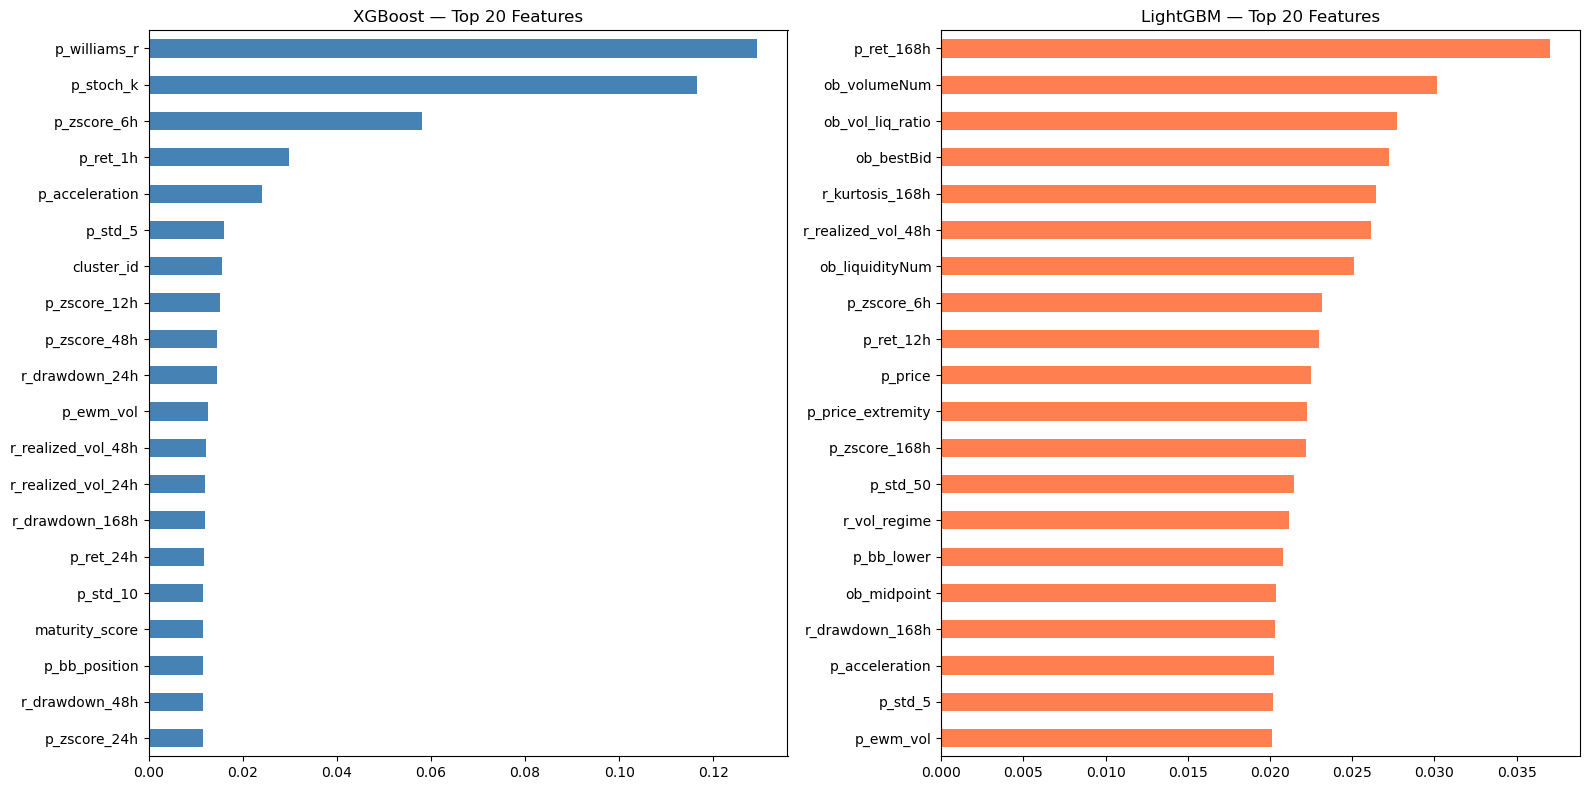


Top-10 by average rank (XGB + LGB):
   1. p_zscore_6h               (avg rank 5.5, XGB: 0.058, LGB: 0.023)
   2. r_realized_vol_48h        (avg rank 9.0, XGB: 0.012, LGB: 0.026)
   3. p_acceleration            (avg rank 11.5, XGB: 0.024, LGB: 0.020)
   4. p_ret_168h                (avg rank 12.5, XGB: 0.011, LGB: 0.037)
   5. p_std_5                   (avg rank 12.5, XGB: 0.016, LGB: 0.020)
   6. p_ret_1h                  (avg rank 13.5, XGB: 0.030, LGB: 0.020)
   7. ob_vol_liq_ratio          (avg rank 14.5, XGB: 0.011, LGB: 0.028)
   8. r_drawdown_168h           (avg rank 15.5, XGB: 0.012, LGB: 0.020)
   9. p_ewm_vol                 (avg rank 15.5, XGB: 0.013, LGB: 0.020)
  10. ob_bestBid                (avg rank 16.0, XGB: 0.011, LGB: 0.027)


In [13]:
fi_xgb = pd.Series(xgb_best.feature_importances_, index=FEATURES).sort_values(ascending=False)
fi_lgb = pd.Series(lgb_best.feature_importances_, index=FEATURES).sort_values(ascending=False)

fi_xgb_norm = fi_xgb / fi_xgb.sum()
fi_lgb_norm = fi_lgb / fi_lgb.sum()

rank_xgb = fi_xgb.rank(ascending=False)
rank_lgb = fi_lgb.rank(ascending=False)
avg_rank = ((rank_xgb + rank_lgb) / 2).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = 20
fi_xgb_norm.head(top_n).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title(f'XGBoost — Top {top_n} Features')
axes[0].invert_yaxis()

fi_lgb_norm.head(top_n).plot.barh(ax=axes[1], color='coral')
axes[1].set_title(f'LightGBM — Top {top_n} Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../../data/models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop-10 by average rank (XGB + LGB):')
for i, (feat, rank) in enumerate(avg_rank.head(10).items()):
    print(f'  {i+1:2d}. {feat:25s} (avg rank {rank:.1f}, XGB: {fi_xgb_norm.get(feat, 0):.3f}, LGB: {fi_lgb_norm.get(feat, 0):.3f})')

In [14]:
top_features_list = avg_rank.index.tolist()

k_values = [10, 20, 30, len(FEATURES)]
print(f'{"K features":>12s} | {"XGB AUC":>10s} | {"LGB AUC":>10s}')
print('-' * 40)

for k in k_values:
    feat_k = top_features_list[:k]
    feat_idx = [FEATURES.index(f) for f in feat_k]

    X_tr_k = X_train[:, feat_idx]
    X_val_k = X_val[:, feat_idx]

    m_xgb = xgb.XGBClassifier(**best_xgb_params)
    m_xgb.fit(X_tr_k, y_train, eval_set=[(X_val_k, y_val)], verbose=False)
    auc_xgb = roc_auc_score(y_val, m_xgb.predict_proba(X_val_k)[:, 1])

    m_lgb = lgb.LGBMClassifier(**best_lgb_params)
    m_lgb.fit(X_tr_k, y_train, eval_set=[(X_val_k, y_val)])
    auc_lgb = roc_auc_score(y_val, m_lgb.predict_proba(X_val_k)[:, 1])

    label = f'{k}' if k < len(FEATURES) else f'{k} (all)'
    print(f'{label:>12s} | {auc_xgb:>10.4f} | {auc_lgb:>10.4f}')

  K features |    XGB AUC |    LGB AUC
----------------------------------------


          10 |     0.6646 |     0.6670


          20 |     0.6866 |     0.6871


          30 |     0.6892 |     0.6900


    63 (all) |     0.6927 |     0.6908


FINAL EVALUATION ON TEST SET
Test period: 2026-02-22 → 2026-03-05
Test samples: 5,263

--- XGBoost ---
Accuracy: 0.6373 | F1: 0.6376 | AUC: 0.6767 | LogLoss: 0.6497
              precision    recall  f1-score   support

          SL       0.63      0.64      0.64      2613
          TP       0.64      0.63      0.64      2650

    accuracy                           0.64      5263
   macro avg       0.64      0.64      0.64      5263
weighted avg       0.64      0.64      0.64      5263

--- LightGBM ---
Accuracy: 0.6437 | F1: 0.6466 | AUC: 0.6777 | LogLoss: 0.6481
              precision    recall  f1-score   support

          SL       0.64      0.64      0.64      2613
          TP       0.65      0.65      0.65      2650

    accuracy                           0.64      5263
   macro avg       0.64      0.64      0.64      5263
weighted avg       0.64      0.64      0.64      5263



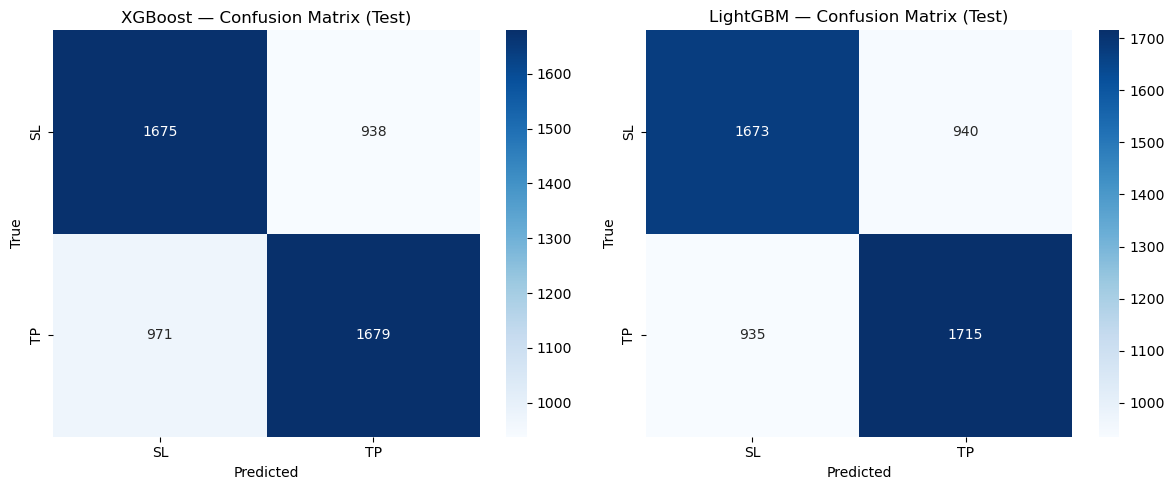

In [15]:
print('='*60)
print('FINAL EVALUATION ON TEST SET')
print('='*60)
print(f'Test period: {test["t0"].min().date()} → {test["t0"].max().date()}')
print(f'Test samples: {len(y_test):,}\n')

models_final = {
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
}

test_results = {}
for name, model in models_final.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)

    test_results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'logloss': ll}

    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | LogLoss: {ll:.4f}')
    print(classification_report(y_test, y_pred, target_names=['SL', 'TP']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models_final.items()):
    y_pred = (model.predict_proba(X_test)[:, 1] > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['SL', 'TP'], yticklabels=['SL', 'TP'])
    ax.set_title(f'{name} — Confusion Matrix (Test)')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../../data/models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

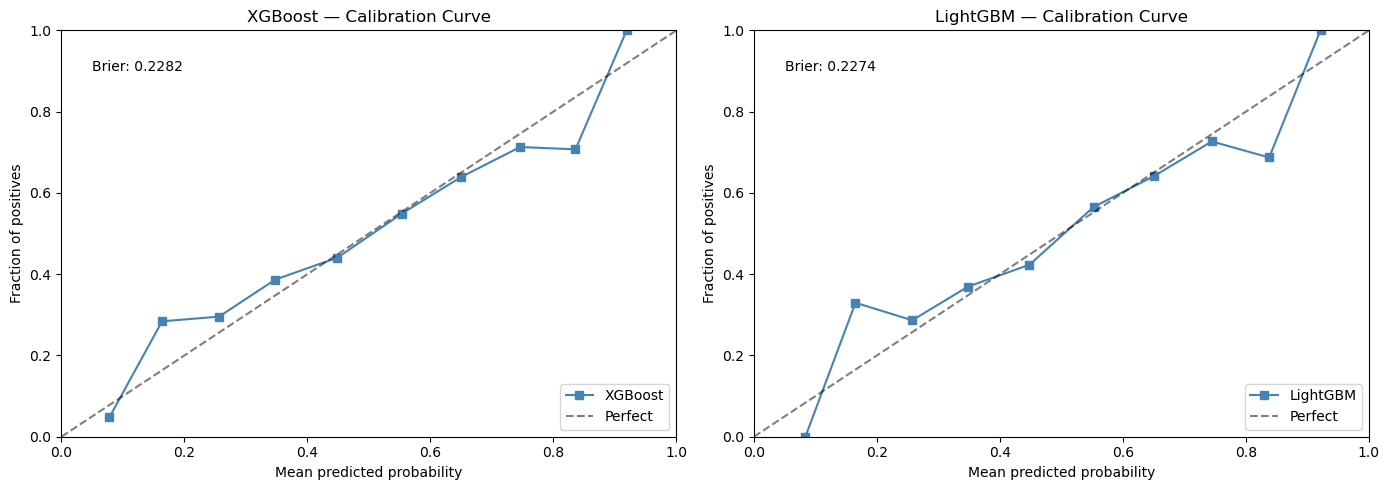

In [16]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models_final.items()):
    y_prob = model.predict_proba(X_test)[:, 1]

    fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

    ax.plot(mean_predicted, fraction_pos, 's-', label=name, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name} — Calibration Curve')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    brier = brier_score_loss(y_test, y_prob)
    ax.text(0.05, 0.9, f'Brier: {brier:.4f}', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../../data/models/calibration.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
res_df = pd.DataFrame(results).T
res_df = res_df[['accuracy', 'f1', 'auc', 'logloss']]

print('\n' + '='*60)
print('MODEL COMPARISON (Validation Set)')
print('='*60)
print(res_df.round(4).to_string())

print('\n' + '='*60)
print('FINAL TEST RESULTS')
print('='*60)
test_df = pd.DataFrame(test_results).T
print(test_df.round(4).to_string())

best_model_name = test_df['auc'].idxmax()
best_auc = test_df.loc[best_model_name, 'auc']
print(f'\nBest model: {best_model_name} (AUC={best_auc:.4f})')


MODEL COMPARISON (Validation Set)
                       accuracy      f1     auc  logloss
Dummy (most frequent)    0.4996  0.0000  0.5000  18.0355
LogisticRegression       0.6366  0.6341  0.6706   0.6501
RandomForest             0.6412  0.6412  0.6893   0.6373
XGBoost (tuned)          0.6382  0.6351  0.6953   0.6324
LightGBM (tuned)         0.6397  0.6390  0.6931   0.6341
XGBoost (PurgedCV)       0.6512  0.6517  0.7058   0.6250
LightGBM (PurgedCV)      0.6557  0.6559  0.7088   0.6225

FINAL TEST RESULTS
          accuracy      f1     auc  logloss
XGBoost     0.6373  0.6376  0.6767   0.6497
LightGBM    0.6437  0.6466  0.6777   0.6481

Best model: LightGBM (AUC=0.6777)


In [18]:
import joblib

best_model = models_final[best_model_name]
model_path = MODELS_DIR / 'best_model_v1.joblib'
joblib.dump(best_model, model_path)

model_meta = {
    'model_name': best_model_name,
    'features': FEATURES,
    'n_features': len(FEATURES),
    'train_medians': train_medians.tolist(),
    'train_samples': len(y_train),
    'val_samples': len(y_val),
    'test_samples': len(y_test),
    'test_metrics': test_results[best_model_name],
    'val_metrics': results.get(f'{best_model_name} (tuned)', results.get(best_model_name, {})),
    'purged_cv_metrics': {
        'XGBoost': {k: f'{v[0]:.4f}±{v[1]:.4f}' for k, v in cv_xgb.items()},
        'LightGBM': {k: f'{v[0]:.4f}±{v[1]:.4f}' for k, v in cv_lgb.items()},
    },
    'best_params': study_xgb.best_params if best_model_name == 'XGBoost' else study_lgb.best_params,
    'label_mapping': {'0': 'SL (stop-loss)', '1': 'TP (take-profit)'},
    'framing': 'binary: TP vs SL (dropped vertical exits)',
    'feature_importance_top10': avg_rank.head(10).index.tolist(),
    'seed': SEED,
}

with open(MODELS_DIR / 'model_meta_v1.json', 'w') as f:
    json.dump(model_meta, f, indent=2, default=str)

print(f'Saved: {model_path} ({model_path.stat().st_size / 1024:.0f} KB)')
print(f'Saved: {MODELS_DIR / "model_meta_v1.json"}')

with open(MODELS_DIR / 'xgb_best_params.json', 'w') as f:
    json.dump(study_xgb.best_params, f, indent=2)
with open(MODELS_DIR / 'lgb_best_params.json', 'w') as f:
    json.dump(study_lgb.best_params, f, indent=2)

Saved: ../../data/models/best_model_v1.joblib (2139 KB)
Saved: ../../data/models/model_meta_v1.json
